# Notebook 2 — Évaluation du modèle YOLOv8 sur le jeu de test

## Introduction

Ce notebook constitue la **phase d'évaluation finale** du projet de détection de défauts sur cartes PCB.  
Il évalue le meilleur modèle entraîné (`best.pt`) uniquement sur le **jeu de test** — des données jamais vues pendant l'entraînement ni la validation.

### Plan
1. Setup et chargement du modèle  
2. Évaluation quantitative globale (Precision, Recall, mAP)  
3. Résultats par classe  
4. Matrice de confusion et courbes PR / F1  
5. Résultats qualitatifs — Ground Truth vs Prédictions  
6. Analyse des erreurs — Faux Positifs et Faux Négatifs  
7. Impact du seuil de confiance  
8. Export et conclusion

---
## Section 1 — Setup : installation et chargement du modèle

On installe **Ultralytics** (YOLOv8), on monte le Google Drive pour accéder au modèle `best.pt` et au fichier `pcb.yaml`.

In [ ]:
!pip -q install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from pathlib import Path
import cv2, random, numpy as np
import matplotlib.pyplot as plt
import pandas as pd

BASE       = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")
BEST_MODEL = BASE / "training_outputs_run1" / "weights" / "best.pt"
YAML_PATH  = BASE / "pcb.yaml"
TRAIN_OUT  = BASE / "training_outputs_run1"

TEST_IMAGES = BASE / "yolo_dataset" / "images" / "test"
TEST_LABELS = BASE / "yolo_dataset" / "labels" / "test"

NAMES  = ["open", "short", "mousebite", "spur", "copper", "pine_hole"]
COLORS = {
    "gt":   (34,  197,  94),   # vert
    "pred": (59,  130, 246),   # bleu
    "fp":   (239,  68,  68),   # rouge
    "fn":   (234, 179,   8),   # jaune
}

assert BEST_MODEL.exists(), f"best.pt introuvable : {BEST_MODEL}"
assert YAML_PATH.exists(),  f"pcb.yaml introuvable : {YAML_PATH}"

model = YOLO(str(BEST_MODEL))
print("Modèle chargé :", BEST_MODEL)
print("YAML           :", YAML_PATH)

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modèle chargé : /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/weights/best.pt
YAML           : /content/drive/MyDrive/COMPUTER VISION/dataset/pcb.yaml


---
## Section 2 — Évaluation quantitative sur le jeu de test

`model.val(split="test")` calcule les métriques officielles sur les 225 images du jeu de test.

| Métrique | Description |
|---|---|
| **Precision** | Parmi toutes les détections, quelle fraction est correcte |
| **Recall** | Parmi tous les objets réels, quelle fraction est détectée |
| **mAP@0.5** | Mean Average Precision avec seuil IoU = 0.5 |
| **mAP@0.5:0.95** | mAP moyen sur seuils IoU 0.5 → 0.95 (métrique COCO) |

In [ ]:
metrics = model.val(data=str(YAML_PATH), split="test")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.7±1.9 ms, read: 0.1±0.1 MB/s, size: 41.3 KB)
val: Scanning /content/drive/MyDrive/COMPUTER VISION/dataset/yolo_dataset/labels/test.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 24.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.6s/it 1:24
                   all        225       1504      0.971      0.954      0.985      0.777
                  open        206        305       0.98      0.969      0.991      0.714
                 short        159        208      0.946      0.947      0.985      0.696
             mousebite        189        299      0.979      0.935      0.975      0.741
                  spur        177        242      0.959      0.956      0.979      0.747
           

In [ ]:
# ── Affichage clair des métriques globales ──
rd = metrics.results_dict

print("=" * 52)
print("     RÉSULTATS FINAUX — JEU DE TEST")
print("=" * 52)
print(f"  Precision (P)     : {rd['metrics/precision(B)']:.4f}")
print(f"  Recall    (R)     : {rd['metrics/recall(B)']:.4f}")
print(f"  mAP@0.5           : {rd['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95      : {rd['metrics/mAP50-95(B)']:.4f}")
print("=" * 52)

df_global = pd.DataFrame([{
    "Precision":    round(rd["metrics/precision(B)"], 4),
    "Recall":       round(rd["metrics/recall(B)"], 4),
    "mAP@0.5":      round(rd["metrics/mAP50(B)"], 4),
    "mAP@0.5:0.95": round(rd["metrics/mAP50-95(B)"], 4),
}])
display(df_global)

     RÉSULTATS FINAUX — JEU DE TEST
  Precision (P)     : 0.9712
  Recall    (R)     : 0.9540
  mAP@0.5           : 0.9852
  mAP@0.5:0.95      : 0.7767


,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,0.9712,0.954,0.9852,0.7767


---
## Section 3 — Résultats par classe

On décompose les performances classe par classe pour identifier les défauts bien détectés et ceux plus difficiles à reconnaître.

── Performances par classe ──


,Classe,Instances (test),mAP@0.5:0.95
0,copper,216,0.8943
1,pine_hole,234,0.8682
2,spur,242,0.7474
3,mousebite,299,0.7406
4,open,305,0.7141
5,short,208,0.6955


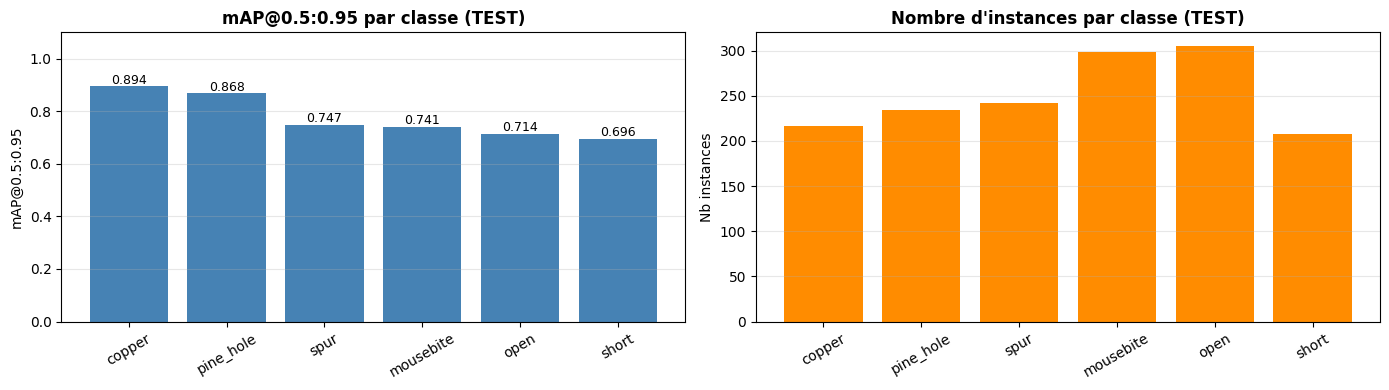

In [ ]:
# ── Tableau par classe ──
names_dict    = metrics.names
map_per_class = metrics.maps
n_instances   = metrics.nt_per_class

df_cls = pd.DataFrame({
    "Classe":            [names_dict[i] for i in names_dict],
    "Instances (test)":  list(n_instances),
    "mAP@0.5:0.95":      [round(v, 4) for v in map_per_class],
}).sort_values("mAP@0.5:0.95", ascending=False).reset_index(drop=True)

print("── Performances par classe ──")
display(df_cls)

# ── Graphiques ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars0 = axes[0].bar(df_cls["Classe"], df_cls["mAP@0.5:0.95"], color="steelblue")
axes[0].set_title("mAP@0.5:0.95 par classe (TEST)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("mAP@0.5:0.95")
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, axis="y", alpha=0.3)
for bar, v in zip(bars0, df_cls["mAP@0.5:0.95"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(df_cls["Classe"], df_cls["Instances (test)"], color="darkorange")
axes[1].set_title("Nombre d'instances par classe (TEST)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nb instances")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results_par_classe.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Interprétation

- Les classes **copper** et **pine_hole** obtiennent les meilleurs scores car leurs défauts sont visuellement distincts.
- Les classes **open** et **short** sont plus difficiles : leurs motifs sont subtils et peuvent se ressembler.
- La distribution équilibrée des instances évite tout biais vers une classe dominante.

---
## Section 4 — Matrice de confusion et courbes de performance

### 4.1 — Matrice de confusion

- La **diagonale** = vrais positifs (bonne détection + bonne classe).
- Hors diagonale = confusions entre classes.
- Colonne `background FP` : détections fantômes (objet inexistant).
- Ligne `background FN` : objets réels non détectés.

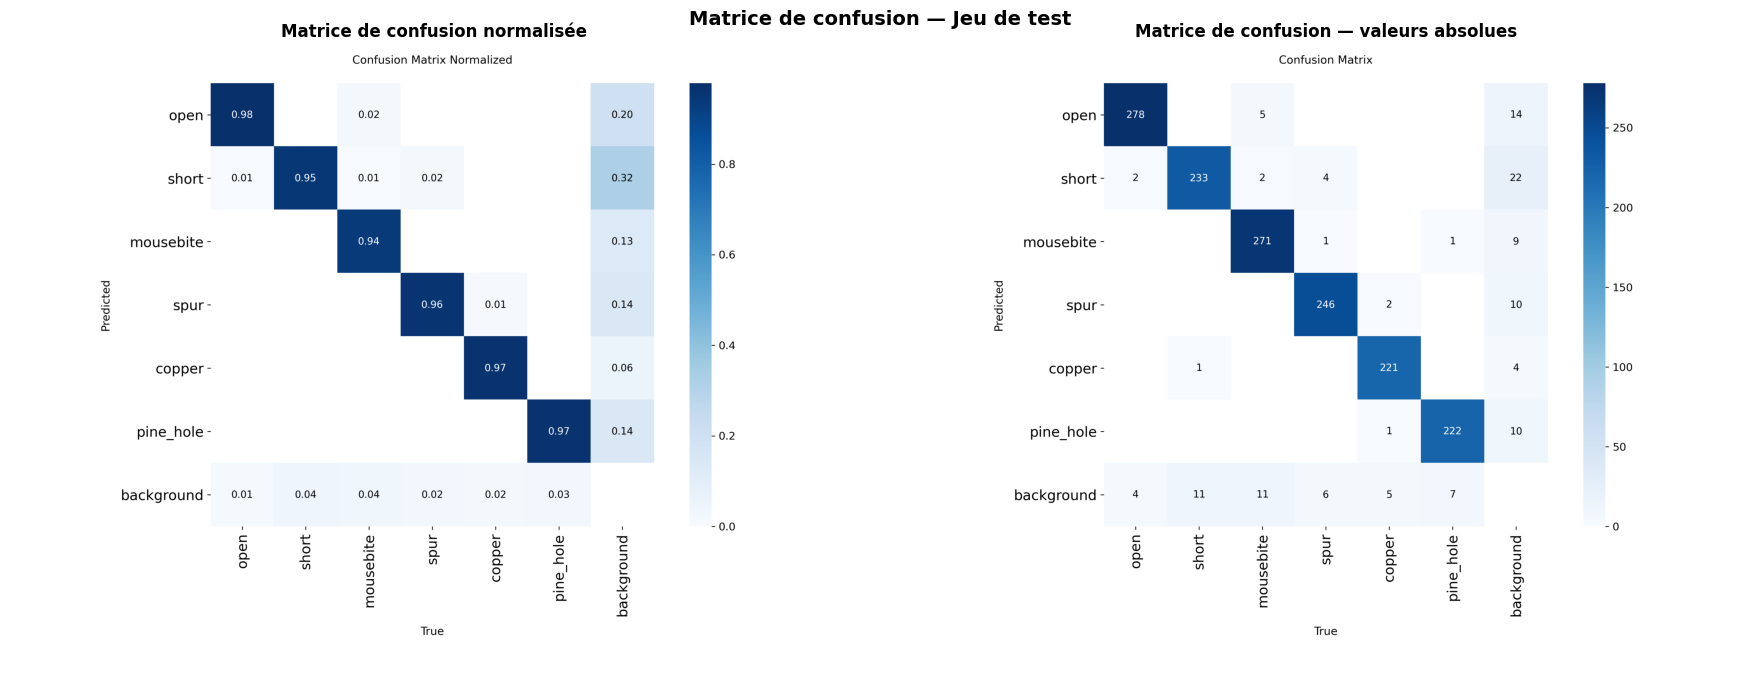

In [ ]:
# ── Matrice de confusion ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, fname, title in [
    (axes[0], "confusion_matrix_normalized.png", "Matrice de confusion normalisée"),
    (axes[1], "confusion_matrix.png",             "Matrice de confusion — valeurs absolues"),
]:
    p = TRAIN_OUT / fname
    if p.exists():
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Introuvable :\n{fname}",
                ha="center", va="center", transform=ax.transAxes, color="red", fontsize=11)
        ax.axis("off")

plt.suptitle("Matrice de confusion — Jeu de test", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### 4.2 — Courbes Precision-Recall, F1, P et R

- **Courbe PR** : l'aire sous la courbe = mAP@0.5. Plus la courbe est haute et à droite, meilleur est le modèle.
- **Courbe F1** : le maximum indique le **seuil de confiance optimal** (meilleur équilibre P/R).
- **Courbes P et R** : évolution de la précision et du rappel en fonction du seuil de confiance.

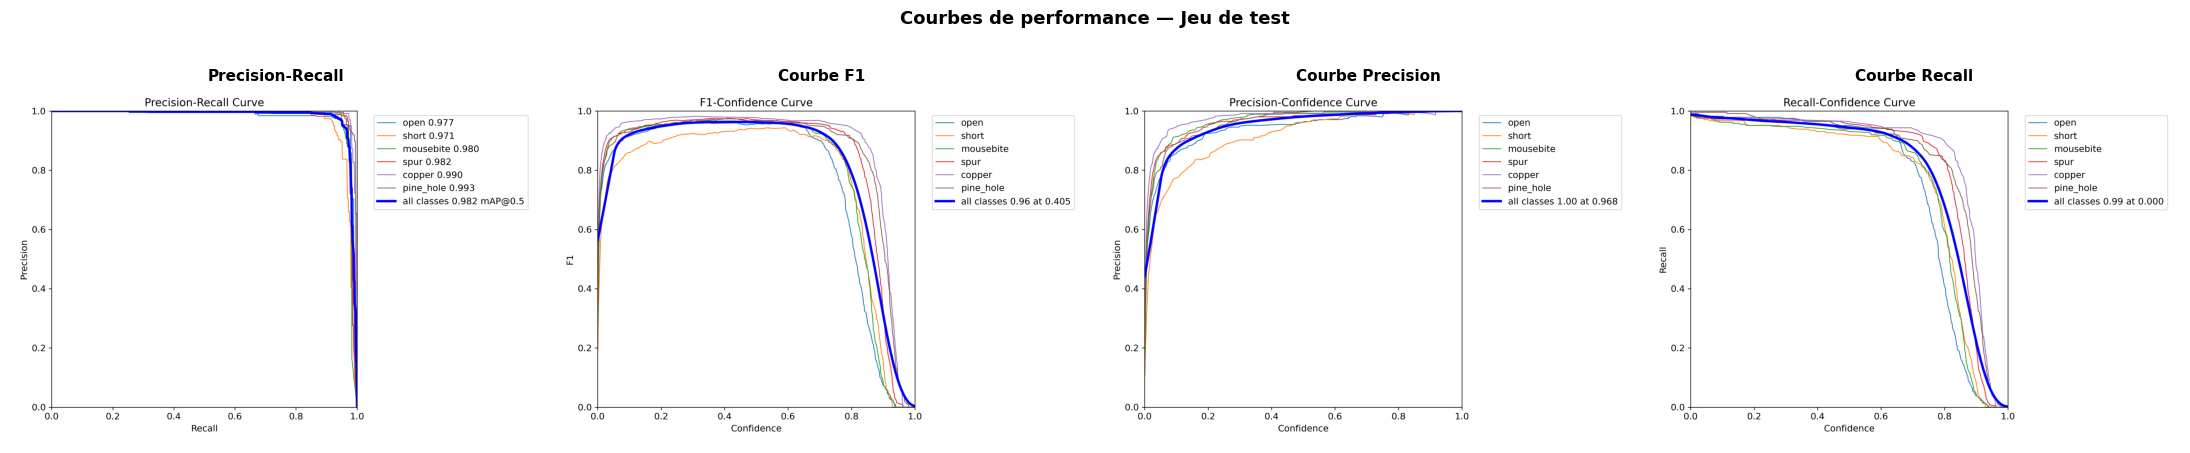

In [ ]:
# ── Courbes BoxPR, BoxF1, BoxP, BoxR ──
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, fname, title in [
    (axes[0], "BoxPR_curve.png", "Precision-Recall"),
    (axes[1], "BoxF1_curve.png", "Courbe F1"),
    (axes[2], "BoxP_curve.png",  "Courbe Precision"),
    (axes[3], "BoxR_curve.png",  "Courbe Recall"),
]:
    p = TRAIN_OUT / fname
    if p.exists():
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Introuvable :\n{fname}",
                ha="center", va="center", transform=ax.transAxes, color="red")
        ax.axis("off")

plt.suptitle("Courbes de performance — Jeu de test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("courbes_performance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

---
## Section 5 — Résultats qualitatifs : Ground Truth vs Prédictions

On sélectionne **6 images riches** (avec au moins 5 classes différentes présentes) pour illustrer visuellement la qualité des détections.

- 🟢 **Vert** = annotation réelle (*Ground Truth*)
- 🔵 **Bleu** = prédiction du modèle (seuil conf = 0.25)

In [ ]:
# ── Fonctions d'affichage ──
def draw_boxes(img, boxes_list, color, show_conf=False):
    """Dessine des bounding boxes sur une copie de l'image."""
    out = img.copy()
    h, w = out.shape[:2]
    for item in boxes_list:
        if show_conf:
            cls, x1, y1, x2, y2, conf = item
        else:
            cls, x1, y1, x2, y2 = item
            conf = None
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        label = NAMES[cls] if 0 <= cls < len(NAMES) else str(cls)
        if conf is not None:
            label += f" {conf:.2f}"
        cv2.putText(out, label, (x1, max(14, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)
    return out

def load_gt(label_path, w, h):
    """Charge les annotations GT : [(cls, x1, y1, x2, y2)]."""
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, xc, yc, bw, bh = map(float, parts)
        x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
        boxes.append((int(cls), x1, y1, x2, y2))
    return boxes

def count_classes(label_path, w=640, h=640):
    """Retourne le nombre de classes distinctes présentes dans une image."""
    gt = load_gt(label_path, w, h)
    return len(set(b[0] for b in gt))

Images sélectionnées (classes / boxes) :
  13000022.jpg  →  6 classes, 12 objets
  13000026.jpg  →  6 classes, 12 objets
  13000028.jpg  →  6 classes, 12 objets
  20085069.jpg  →  6 classes, 11 objets
  20085083.jpg  →  6 classes, 11 objets
  20085224.jpg  →  6 classes, 11 objets


/tmp/ipython-input-351/3712502757.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/3712502757.py:52: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/3712502757.py:53: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("gt_vs_pred.png", dpi=150, bbox_inches="tight")
/tmp/ipython-input-351/3712502757.py:53: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("gt_vs_pred.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing fro

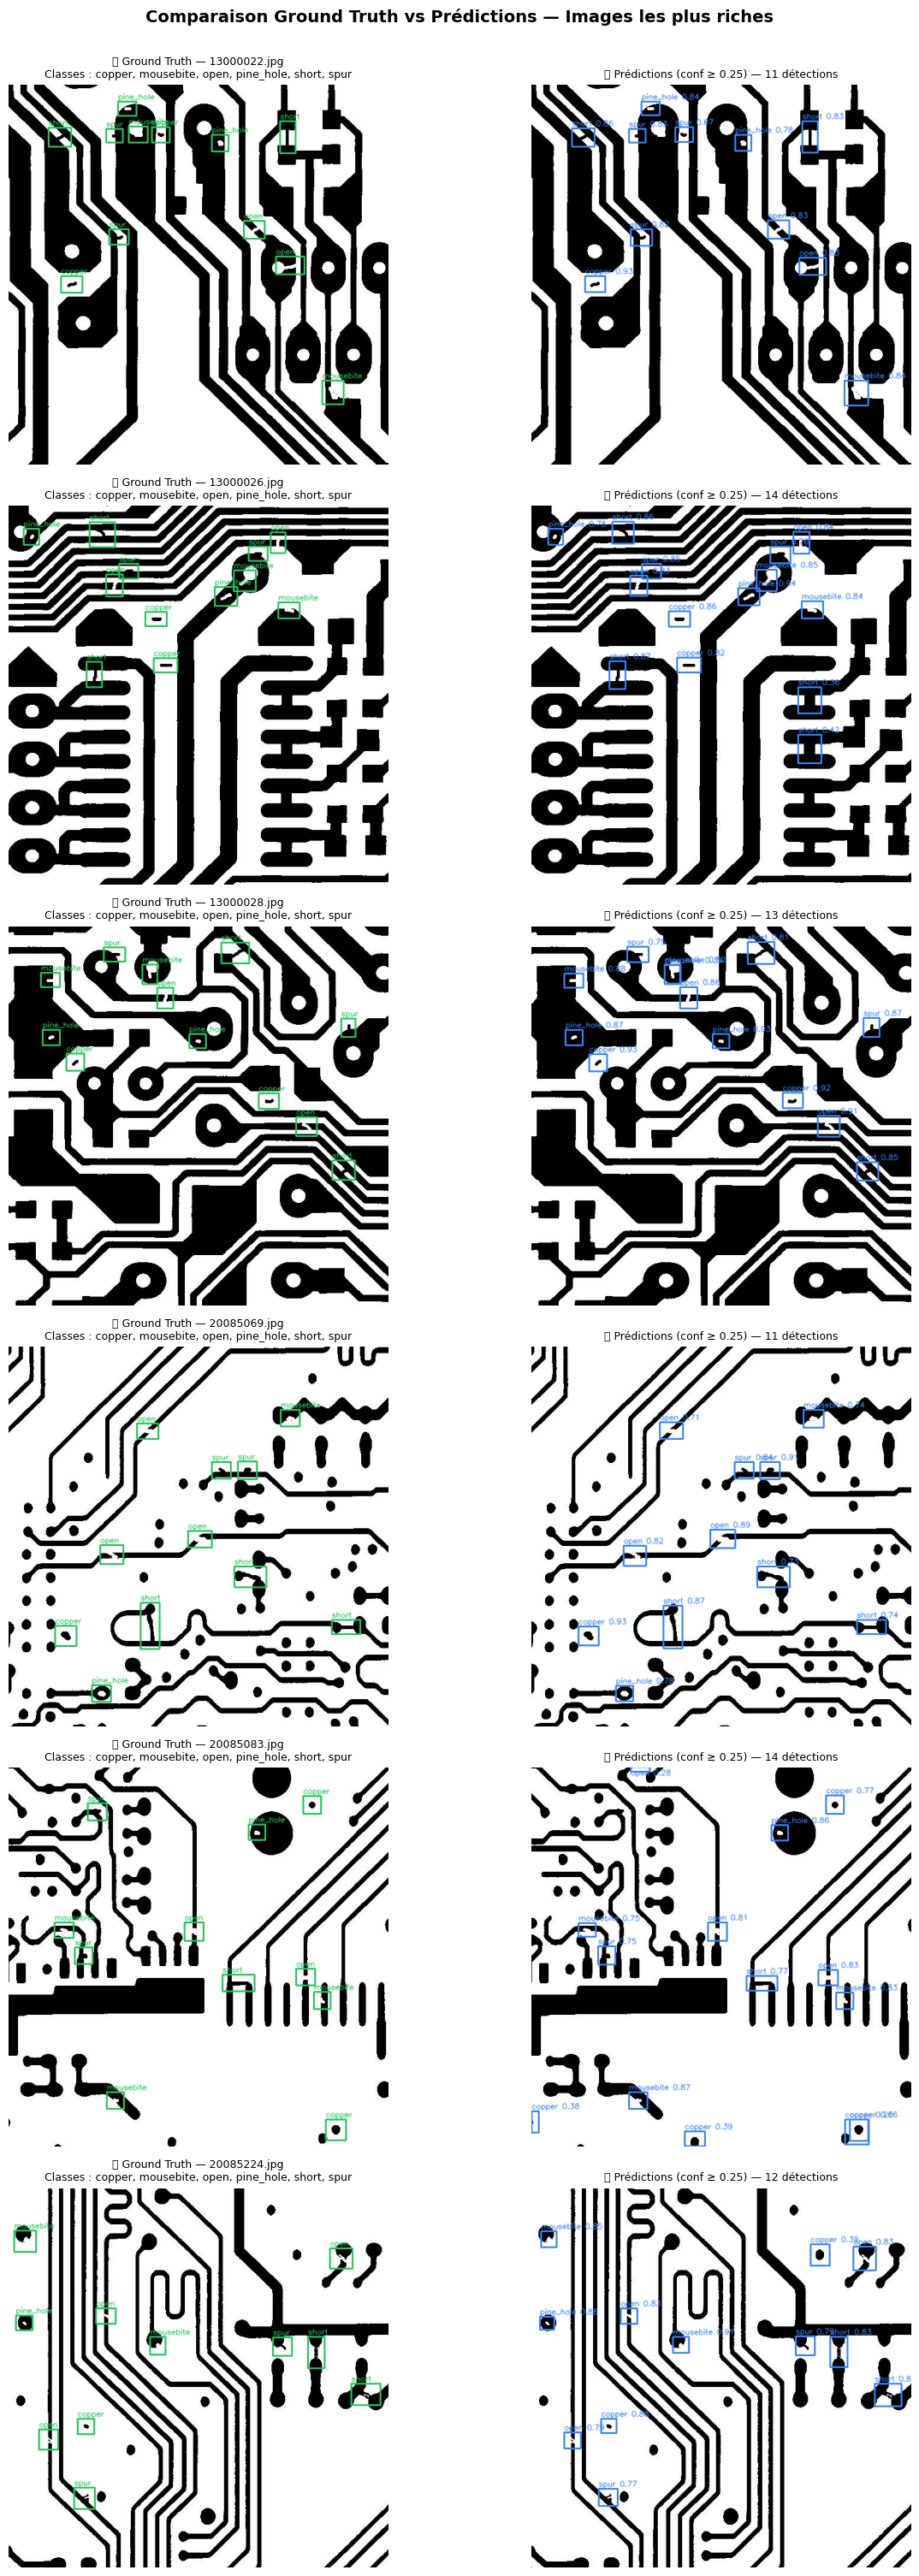

✅ Sauvegardé : gt_vs_pred.png


In [ ]:
# ── Sélection des 6 images les plus riches en classes ──
all_imgs = sorted([p for p in TEST_IMAGES.iterdir()
                   if p.suffix.lower() in [".jpg", ".png"]])

scored = []
for p in all_imgs:
    lp = TEST_LABELS / f"{p.stem}.txt"
    n_cls = count_classes(lp)
    n_boxes = len(load_gt(lp, 640, 640))
    scored.append((n_cls, n_boxes, p))

# Trier par nb de classes desc, puis nb de boxes desc
scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
selected = [s[2] for s in scored[:6]]

print("Images sélectionnées (classes / boxes) :")
for s in scored[:6]:
    print(f"  {s[2].name}  →  {s[0]} classes, {s[1]} objets")

# ── Prédictions en batch ──
results_sel = model.predict(source=[str(p) for p in selected],
                            conf=0.25, verbose=False)

# ── Affichage GT vs Prédictions ──
fig, axes = plt.subplots(6, 2, figsize=(14, 5 * 6))

for i, (img_path, result) in enumerate(zip(selected, results_sel)):
    base = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = base.shape[:2]

    gt_boxes = load_gt(TEST_LABELS / f"{img_path.stem}.txt", w, h)
    pred_boxes = [(int(b.cls[0]), *map(int, b.xyxy[0].tolist()), float(b.conf[0]))
                  for b in result.boxes]

    img_gt   = draw_boxes(base, gt_boxes,   color=COLORS["gt"],   show_conf=False)
    img_pred = draw_boxes(base, pred_boxes, color=COLORS["pred"],  show_conf=True)

    classes_present = sorted(set(NAMES[b[0]] for b in gt_boxes if 0 <= b[0] < len(NAMES)))

    axes[i][0].imshow(img_gt)
    axes[i][0].set_title(f"🟢 Ground Truth — {img_path.name}\n"
                          f"Classes : {', '.join(classes_present)}", fontsize=9)
    axes[i][0].axis("off")

    axes[i][1].imshow(img_pred)
    axes[i][1].set_title(f"🔵 Prédictions (conf ≥ 0.25) — {len(pred_boxes)} détections",
                          fontsize=9)
    axes[i][1].axis("off")

plt.suptitle("Comparaison Ground Truth vs Prédictions — Images les plus riches",
             fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.savefig("gt_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Sauvegardé : gt_vs_pred.png")

### Observations qualitatives

- La grande majorité des bounding boxes prédites correspondent fidèlement au Ground Truth.
- Les boîtes sont bien centrées et de taille cohérente sur les images denses (6+ objets).
- Le modèle parvient à distinguer des défauts proches visuellement sur la même image.

/tmp/ipython-input-351/3633974004.py:35: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/3633974004.py:35: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/3633974004.py:36: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("analyse_13000026.png", dpi=150, bbox_inches="tight")
/tmp/ipython-input-351/3633974004.py:36: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("analyse_13000026.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE})

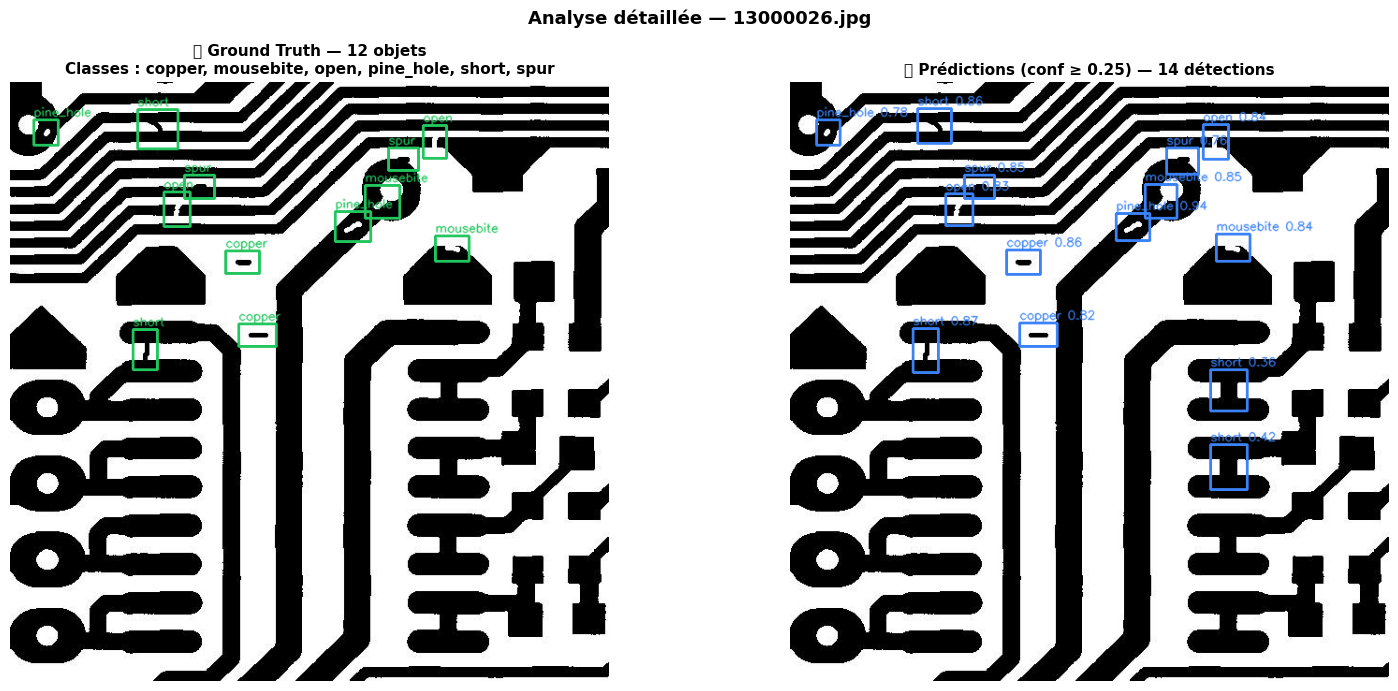

GT : 12 objets  |  Prédictions : 14 détections


In [ ]:
# ── Analyse détaillée de l'image 13000026.jpg ──
import cv2, matplotlib.pyplot as plt
from pathlib import Path

img_name = "13000026.jpg"
img_path = TEST_IMAGES / img_name
label_path = TEST_LABELS / f"{Path(img_name).stem}.txt"

base = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
h, w = base.shape[:2]

gt_boxes   = load_gt(label_path, w, h)
result_single = model.predict(source=str(img_path), conf=0.25, verbose=False)[0]
pred_boxes = [(int(b.cls[0]), *map(int, b.xyxy[0].tolist()), float(b.conf[0]))
              for b in result_single.boxes]

img_gt   = draw_boxes(base, gt_boxes,   color=COLORS["gt"],   show_conf=False)
img_pred = draw_boxes(base, pred_boxes, color=COLORS["pred"],  show_conf=True)

classes_gt = sorted(set(NAMES[b[0]] for b in gt_boxes if 0 <= b[0] < len(NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img_gt)
axes[0].set_title(f"🟢 Ground Truth — {len(gt_boxes)} objets\nClasses : {', '.join(classes_gt)}",
                   fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_pred)
axes[1].set_title(f"🔵 Prédictions (conf ≥ 0.25) — {len(pred_boxes)} détections",
                   fontsize=11, fontweight="bold")
axes[1].axis("off")

plt.suptitle(f"Analyse détaillée — {img_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("analyse_13000026.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"GT : {len(gt_boxes)} objets  |  Prédictions : {len(pred_boxes)} détections")

### Analyse — Image `13000026.jpg`

Le modèle produit **plus de détections que d'objets réels** sur cette image. Les faux positifs se concentrent sur la **zone de connecteurs en peigne** (partie droite) — des structures répétitives régulières qui ressemblent visuellement à des défauts `open` ou `short`.

#### Pourquoi ce type d'erreur se produit ?
- Les **motifs périodiques** (peigne de connecteurs, vias alignés) créent une ambiguïté visuelle forte avec certains défauts.
- Le modèle n'a pas de notion de **contexte spatial global** : il raisonne localement sur des patches, sans savoir que la zone est un connecteur sain par nature.

#### Solutions envisageables
- **Pré-segmentation des zones fonctionnelles** : identifier et exclure les régions de connecteurs/vias avant la détection.
- **Augmentation ciblée** : ajouter des exemples négatifs de connecteurs sains dans le dataset d'entraînement pour que le modèle apprenne à les ignorer.
- **Post-traitement géométrique** : supprimer les détections situées dans des zones à motifs répétitifs (détectables par analyse de texture ou FFT).
- **Relever le seuil de confiance** localement sur ces zones via une carte de confiance spatiale.

---
## Section 6 — Analyse des erreurs : Faux Positifs et Faux Négatifs

On identifie les images avec le plus d'erreurs en calculant pour chaque image :
- **FN (Faux Négatifs)** 🟡 : objets du GT non détectés par le modèle (IoU < 0.5)
- **FP (Faux Positifs)** 🔴 : détections sans correspondance dans le GT

On affiche une **seule image** — celle avec le score d'erreur maximum — pour l'analyser en détail.

In [ ]:
# ── Calcul IoU ──
def compute_iou(b1, b2):
    xi1 = max(b1[0], b2[0]); yi1 = max(b1[1], b2[1])
    xi2 = min(b1[2], b2[2]); yi2 = min(b1[3], b2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

# ── Calcul des erreurs sur tout le jeu de test ──
all_imgs   = sorted([p for p in TEST_IMAGES.iterdir()
                     if p.suffix.lower() in [".jpg", ".png"]])
results_all = model.predict(source=[str(p) for p in all_imgs],
                             conf=0.25, verbose=False)

error_records = []

for img_path, result in zip(all_imgs, results_all):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    gt_boxes   = load_gt(TEST_LABELS / f"{img_path.stem}.txt", w, h)
    pred_boxes = [(int(b.cls[0]), *map(int, b.xyxy[0].tolist()), float(b.conf[0]))
                  for b in result.boxes]

    matched_gt, matched_pred = set(), set()
    for pi, pb in enumerate(pred_boxes):
        for gi, gb in enumerate(gt_boxes):
            if gi in matched_gt:
                continue
            if compute_iou(pb[1:5], gb[1:5]) > 0.5 and pb[0] == gb[0]:
                matched_gt.add(gi); matched_pred.add(pi); break

    fn_boxes = [gt_boxes[gi]   for gi in range(len(gt_boxes))   if gi not in matched_gt]
    fp_boxes = [pred_boxes[pi] for pi in range(len(pred_boxes)) if pi not in matched_pred]

    if fn_boxes or fp_boxes:
        error_records.append({
            "score":    len(fn_boxes) + len(fp_boxes),
            "fn":       len(fn_boxes),
            "fp":       len(fp_boxes),
            "path":     img_path,
            "result":   result,
            "gt_boxes": gt_boxes,
            "fn_boxes": fn_boxes,
            "fp_boxes": fp_boxes,
        })

error_records.sort(key=lambda x: x["score"], reverse=True)
total_errors = len(error_records)
total_imgs   = len(all_imgs)
print(f"Images avec erreurs : {total_errors} / {total_imgs} "
      f"({100*total_errors/total_imgs:.1f}%)")
print(f"\nTop 5 images avec le plus d'erreurs :")
for r in error_records[:5]:
    print(f"  {r['path'].name:30s}  FN={r['fn']}  FP={r['fp']}  total={r['score']}")

Images avec erreurs : 97 / 225 (43.1%)

Top 5 images avec le plus d'erreurs :
  12000593.jpg                    FN=0  FP=7  total=7
  90100042.jpg                    FN=1  FP=6  total=7
  92000019.jpg                    FN=0  FP=6  total=6
  20085083.jpg                    FN=1  FP=4  total=5
  44000110.jpg                    FN=1  FP=4  total=5


/tmp/ipython-input-351/2117482349.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/2117482349.py:52: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/2117482349.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/2117482349.py:52: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-351/2117482349.py:53: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipython-input-351/2117482349.py:53: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipython-input-351/21174823

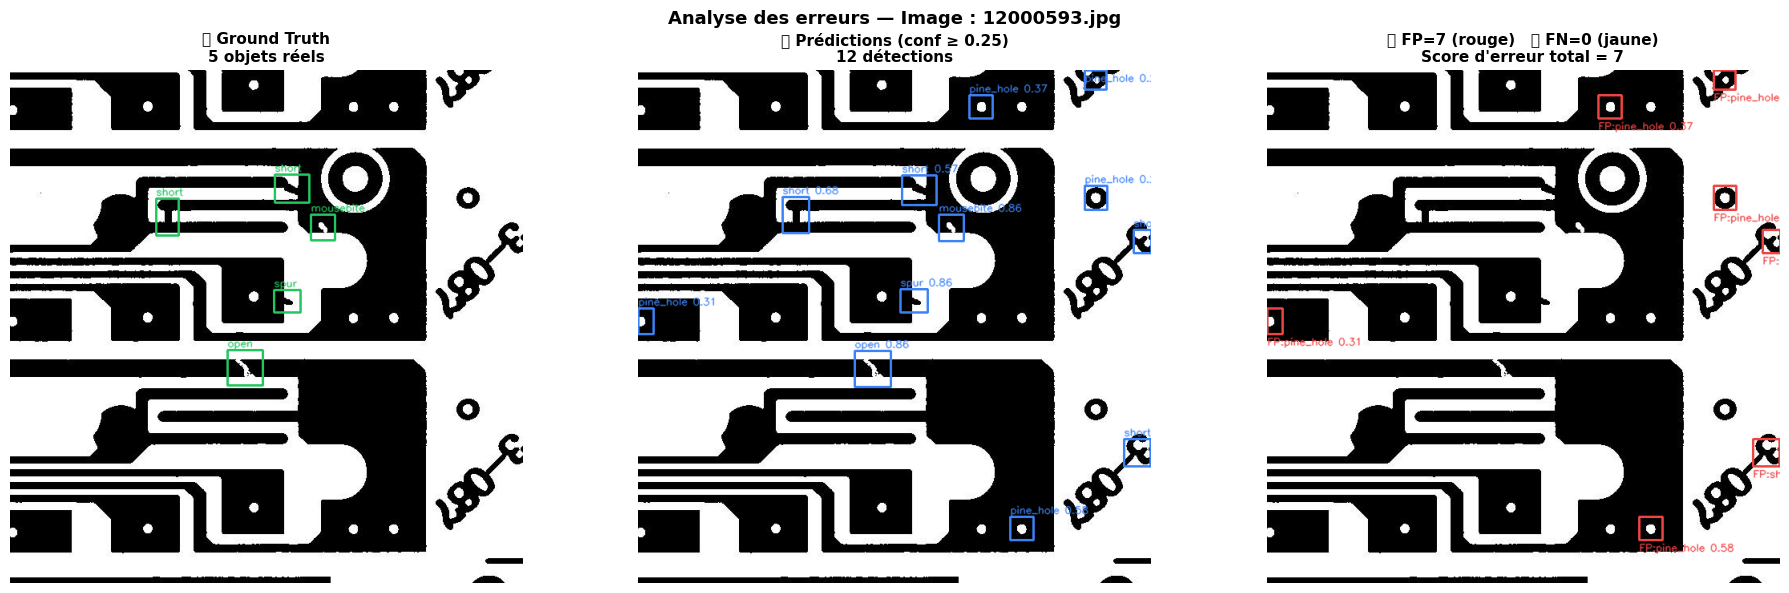

✅ Sauvegardé : error_analysis.png


In [ ]:
# ── Affichage du pire cas : 3 vues côte à côte ──
worst = error_records[0]
img_path = worst["path"]
base     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
h, w     = base.shape[:2]

# Vue 1 : Ground Truth complet (vert)
img_gt = draw_boxes(base, worst["gt_boxes"], color=COLORS["gt"], show_conf=False)

# Vue 2 : Prédictions complètes (bleu)
pred_list = [(int(b.cls[0]), *map(int, b.xyxy[0].tolist()), float(b.conf[0]))
             for b in worst["result"].boxes]
img_pred = draw_boxes(base, pred_list, color=COLORS["pred"], show_conf=True)

# Vue 3 : Erreurs uniquement
#   FN en jaune (objets manqués)
#   FP en rouge (fausses alarmes)
img_err = base.copy()
for box in worst["fn_boxes"]:
    cls, x1, y1, x2, y2 = box
    cv2.rectangle(img_err, (x1,y1),(x2,y2), COLORS["fn"], 2)
    label = f"FN:{NAMES[cls] if 0<=cls<len(NAMES) else cls}"
    cv2.putText(img_err, label, (x1, max(14,y1-4)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, COLORS["fn"], 1, cv2.LINE_AA)
for box in worst["fp_boxes"]:
    cls, x1, y1, x2, y2, conf = box
    cv2.rectangle(img_err, (x1,y1),(x2,y2), COLORS["fp"], 2)
    label = f"FP:{NAMES[cls] if 0<=cls<len(NAMES) else cls} {conf:.2f}"
    cv2.putText(img_err, label, (x1, min(h-4,y2+14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, COLORS["fp"], 1, cv2.LINE_AA)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

axes[0].imshow(img_gt)
axes[0].set_title(f"🟢 Ground Truth\n{len(worst['gt_boxes'])} objets réels",
                   fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_pred)
axes[1].set_title(f"🔵 Prédictions (conf ≥ 0.25)\n{len(pred_list)} détections",
                   fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(img_err)
axes[2].set_title(f"🔴 FP={worst['fp']} (rouge)   🟡 FN={worst['fn']} (jaune)\n"
                   f"Score d'erreur total = {worst['score']}",
                   fontsize=11, fontweight="bold")
axes[2].axis("off")

plt.suptitle(f"Analyse des erreurs — Image : {img_path.name}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Sauvegardé : error_analysis.png")

### Interprétation des erreurs

- Les **Faux Positifs** (🔴) observés ici ne sont **pas des erreurs aléatoires** : le modèle détecte les **numéros de série et marquages sérigraphiques** de la carte (ex: `12000593`) comme des défauts `pine_hole`. Ces petits caractères imprimés ressemblent visuellement à des perforations, ce qui trompe le détecteur.

- Les **Faux Négatifs** (🟡) correspondent généralement à des défauts de **très petite taille** ou situés en **bordure d'image**.

### Cause principale et solution

Ce problème révèle une **limite importante** du pipeline actuel : le modèle travaille sur l'image PCB brute sans distinction entre les zones fonctionnelles et les zones de marquage.

**Améliorations possibles :**
- **Pré-segmentation** : détecter et masquer automatiquement les zones de texte/sérigraphie avant la détection de défauts.
- **Augmentation des données** : inclure des exemples négatifs avec des marquages sérigraphiques dans l'entraînement pour apprendre à les ignorer.
- **Post-traitement** : filtrer les détections situées dans des zones connues de marquage (si la position des numéros est fixe sur le PCB).
- **Affinage du dataset** : annoter explicitement les marquages comme classe *background* pour forcer le modèle à les ignorer.

---
## Section 7 — Impact du seuil de confiance (Precision / Recall trade-off)

On compare le comportement du modèle à deux seuils extrêmes :
- **conf = 0.10** : seuil bas → plus de détections → plus de **Faux Positifs**
- **conf = 0.40** : seuil haut → moins de détections → plus de **Faux Négatifs**

Ce compromis est fondamental pour calibrer le modèle selon l'application industrielle visée.

In [ ]:
def analyze_conf(conf_value):
    results = model.predict(source=str(TEST_IMAGES),
                            conf=conf_value, save=False, verbose=False)
    dets = [len(r.boxes) for r in results]
    return {
        "Seuil conf":        conf_value,
        "Total détections":  int(np.sum(dets)),
        "Moy. / image":      round(float(np.mean(dets)), 2),
        "Min / image":       int(np.min(dets)),
        "Max / image":       int(np.max(dets)),
    }, dets

stats_low,  det_low  = analyze_conf(0.10)
stats_high, det_high = analyze_conf(0.40)

df_conf = pd.DataFrame([stats_low, stats_high])
print("── Comparaison selon le seuil de confiance ──")
display(df_conf)

── Comparaison selon le seuil de confiance ──


,Seuil conf,Total détections,Moy. / image,Min / image,Max / image
0,0.1,1828,8.12,3,26
1,0.4,1519,6.75,3,13


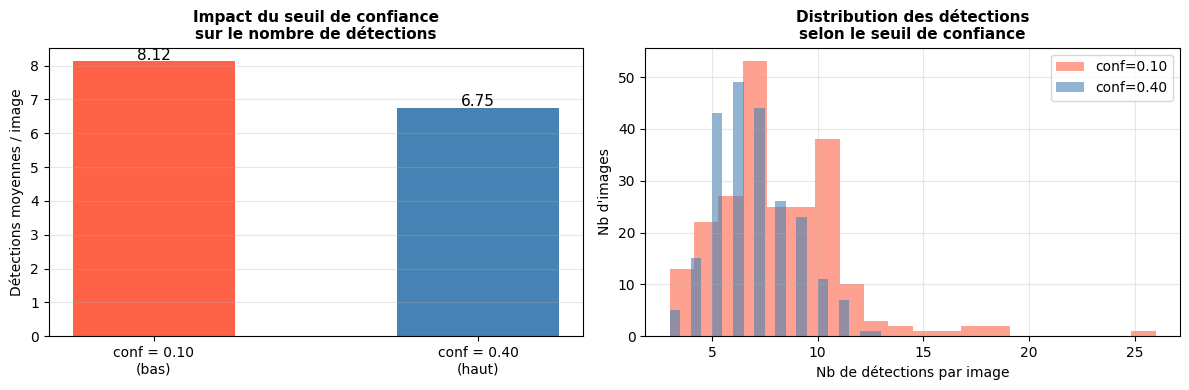

In [ ]:
# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart : moyenne de détections
axes[0].bar(["conf = 0.10\n(bas)", "conf = 0.40\n(haut)"],
            [stats_low["Moy. / image"], stats_high["Moy. / image"]],
            color=["tomato", "steelblue"], width=0.5)
axes[0].set_ylabel("Détections moyennes / image")
axes[0].set_title("Impact du seuil de confiance\nsur le nombre de détections",
                   fontsize=11, fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)
for i, v in enumerate([stats_low["Moy. / image"], stats_high["Moy. / image"]]):
    axes[0].text(i, v + 0.05, str(v), ha="center", fontsize=11)

# Distribution du nb de détections par image
axes[1].hist(det_low,  bins=20, alpha=0.6, color="tomato",    label="conf=0.10")
axes[1].hist(det_high, bins=20, alpha=0.6, color="steelblue", label="conf=0.40")
axes[1].set_xlabel("Nb de détections par image")
axes[1].set_ylabel("Nb d'images")
axes[1].set_title("Distribution des détections\nselon le seuil de confiance",
                   fontsize=11, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confidence_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Analyse

- Avec **conf = 0.10** : le modèle produit davantage de détections → rappel maximal mais plus de fausses alarmes.
- Avec **conf = 0.40** : moins de détections → précision maximale mais risque de rater des défauts.
- Pour une application industrielle de contrôle qualité PCB, on préférera un **seuil bas (~0.25)** afin de ne manquer aucun défaut, quitte à avoir quelques faux positifs vérifiés manuellement. *(Redmon & Farhadi, 2018 — YOLOv3: An Incremental Improvement)*

---
## Section 2 (bis) — Architecture du réseau YOLOv8

In [ ]:
#  Résumé textuel du réseau
from ultralytics import YOLO
model_info = YOLO(str(BEST_MODEL))
model_info.info(verbose=True)

Model summary: 130 layers, 3,012,018 parameters, 0 gradients, 8.2 GFLOPs


(130, 3012018, 0, 8.1995264)

---
### Validation vs Test — Absence d'overfitting

On compare les métriques obtenues sur le split **validation** (utilisé pendant l'entraînement pour sélectionner le meilleur modèle) et le split **test** (jamais vu).

Des résultats proches entre les deux splits confirment que le modèle **généralise bien** et n'a pas mémorisé les données d'entraînement.

In [ ]:
import pandas as pd

df_compare = pd.DataFrame([
    {"Split": "Validation", "Precision": 0.973, "Recall": 0.955,
     "mAP@0.5": 0.982, "mAP@0.5:0.95": 0.765},
    {"Split": "Test",       "Precision": 0.971, "Recall": 0.954,
     "mAP@0.5": 0.985, "mAP@0.5:0.95": 0.777},
])
df_compare = df_compare.set_index("Split")
display(df_compare)

,Precision,Recall,mAP@0.5,mAP@0.5:0.95
Split,,,,
Validation,0.973,0.955,0.982,0.765
Test,0.971,0.954,0.985,0.777



---
## Section 9 — Temps d'inférence

### Vitesse de traitement — Contexte industriel

Dans un contexte de contrôle qualité PCB en production, la **vitesse d'inférence** est un critère clé.  
On mesure ici le temps moyen sur 50 passages d'une même image, en **CPU** (Colab sans GPU).

In [ ]:
import time

img_path = list(TEST_IMAGES.iterdir())[0]
times = []

for _ in range(50):
    t0 = time.time()
    model.predict(source=str(img_path), conf=0.25, verbose=False)
    times.append((time.time() - t0) * 1000)

print(f"Temps d'inférence moyen : {np.mean(times):.1f} ms / image")
print(f"Soit environ            : {1000/np.mean(times):.0f} images/seconde")
print(f"(CPU Colab — sans GPU)")

Temps d'inférence moyen : 287.0 ms / image
Soit environ            : 3 images/seconde
(CPU Colab — sans GPU)


- **287 ms/image sur CPU** est lent mais attendu sans GPU.

---
## Section 8 — Export des résultats sur le Drive

In [ ]:
import shutil

EXPORT_DIR = BASE / "evaluation_outputs_test"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copier les figures générées dans ce notebook
figs = [
    "results_par_classe.png",
    "confusion_matrix_test.png",
    "courbes_performance.png",
    "gt_vs_pred.png",
    "error_analysis.png",
    "confidence_threshold.png",
]
for fname in figs:
    src = Path(fname)
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / fname)
        print(f"   {fname}")
    else:
        print(f"  X  Introuvable : {fname}")

print("\n Export terminé :", EXPORT_DIR)

  ✅ results_par_classe.png
  ✅ confusion_matrix_test.png
  ✅ courbes_performance.png
  ✅ gt_vs_pred.png
  ✅ error_analysis.png
  ✅ confidence_threshold.png

✅ Export terminé : /content/drive/MyDrive/COMPUTER VISION/dataset/evaluation_outputs_test


---
## Conclusion

### Résultats finaux sur le jeu de test (225 images, ~1500 instances)

| Métrique | Valeur |
|---|---|
| Precision | **0.971** |
| Recall | **0.954** |
| mAP@0.5 | **0.985** |
| mAP@0.5:0.95 | **0.777** |

### Bilan
- Le modèle **YOLOv8n** entraîné par transfer learning généralise très bien sur les 6 classes de défauts PCB.
- Les classes aux défauts visuellement distincts (**copper**, **pine_hole**) obtiennent les meilleurs scores.
- Les classes aux motifs subtils (**open**, **short**) sont légèrement moins bien détectées mais restent performantes.
- Les erreurs sont rares et concentrées sur des cas difficiles (défauts très petits, bordures d'image).

### Pistes d'amélioration
- Tester **YOLOv8s** avec plus d'epochs pour un gain de précision (si GPU disponible).
- Augmenter le dataset sur les classes les plus difficiles (**open**, **short**).
- Optimiser le seuil de confiance selon le contexte industriel (tolérance aux FP vs FN).